# Keypoint MoSeq Analysis

Behavioral segmentation of JARVIS 3D keypoint predictions using [keypoint-moseq](https://keypoint-moseq.readthedocs.io/).


In [7]:
# Environment setup - must be before JAX imports
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import jax
print(f"JAX devices: {jax.devices()}")
import keypoint_moseq as kpms

JAX devices: [StreamExecutorGpuDevice(id=0, process_index=0)]


## Custom Loader for JARVIS data3D.csv

In [8]:
import json

def load_skeleton(skeleton_path):
    """
    Load skeleton definition from JSON file.

    Args:
        skeleton_path: Path to skeleton JSON file (e.g., fly50.json)

    Returns:
        node_names: list of keypoint names
        edges: list of [name1, name2] pairs for skeleton connectivity
        edges_idx: list of [idx1, idx2] pairs (original numeric format)
    """
    with open(skeleton_path, 'r') as f:
        skeleton = json.load(f)

    node_names = skeleton['node_names']
    edges_idx = skeleton['edges']

    # Convert numeric edges to named edges
    edges = [[node_names[e[0]], node_names[e[1]]] for e in edges_idx]

    return node_names, edges, edges_idx


def load_jarvis_3d(csv_path):
    """
    Load JARVIS data3D.csv into keypoint-moseq format.

    Args:
        csv_path: Path to data3D.csv file

    Returns:
        coordinates: dict mapping recording name to array (n_frames, n_keypoints, 3)
        confidences: dict mapping recording name to array (n_frames, n_keypoints)
        bodyparts: list of keypoint names
    """
    # Read multi-level header CSV
    df = pd.read_csv(csv_path, header=[0, 1])

    # Get unique keypoint names (from level 0)
    bodyparts = df.columns.get_level_values(0).unique().tolist()

    n_frames = len(df)
    n_keypoints = len(bodyparts)

    # Extract coordinates and confidences
    coords = np.zeros((n_frames, n_keypoints, 3))
    confs = np.zeros((n_frames, n_keypoints))

    for i, kp in enumerate(bodyparts):
        coords[:, i, 0] = df[(kp, 'x')].values
        coords[:, i, 1] = df[(kp, 'y')].values
        coords[:, i, 2] = df[(kp, 'z')].values
        confs[:, i] = df[(kp, 'confidence')].values

    # Use filename as recording name
    rec_name = Path(csv_path).stem

    coordinates = {rec_name: coords}
    confidences = {rec_name: confs}

    return coordinates, confidences, bodyparts


def load_multiple_jarvis(csv_paths):
    """
    Load multiple JARVIS CSVs into a single coordinates dict.

    Args:
        csv_paths: List of paths to data3D.csv files

    Returns:
        coordinates, confidences, bodyparts
    """
    all_coords = {}
    all_confs = {}
    bodyparts = None

    for csv_path in csv_paths:
        coords, confs, bp = load_jarvis_3d(csv_path)
        all_coords.update(coords)
        all_confs.update(confs)
        if bodyparts is None:
            bodyparts = bp

    return all_coords, all_confs, bodyparts

## Load Data

In [9]:
# Path to your JARVIS predictions
csv_path = '/home/user/src/JARVIS-HybridNet/projects/fly50_V4/predictions/predictions3D/Predictions_3D_20260114-140622/data3D.csv'

# Path to skeleton definition
skeleton_path = '/home/user/red_data/skeleton/fly50.json'

# Load data
coordinates, confidences, bodyparts = load_jarvis_3d(csv_path)

# Load skeleton
skeleton_nodes, skeleton_edges, skeleton_edges_idx = load_skeleton(skeleton_path)

# Check the data
rec_name = list(coordinates.keys())[0]
print(f"Recording: {rec_name}")
print(f"Shape: {coordinates[rec_name].shape}")
print(f"Keypoints ({len(bodyparts)}): {bodyparts[:10]}...")
print(f"\nSkeleton edges ({len(skeleton_edges)}): {skeleton_edges[:5]}...")

Recording: data3D
Shape: (2000, 50, 3)
Keypoints (50): ['Antenna_Base', 'EyeL', 'EyeR', 'Scutellum', 'Abd_A4', 'Abd_tip', 'WingL_base', 'WingL_V12', 'WingL_V13', 'T1L_ThxCx']...

Skeleton edges (44): [['Antenna_Base', 'EyeL'], ['Antenna_Base', 'EyeR'], ['EyeL', 'Scutellum'], ['EyeR', 'Scutellum'], ['Scutellum', 'Abd_A4']]...


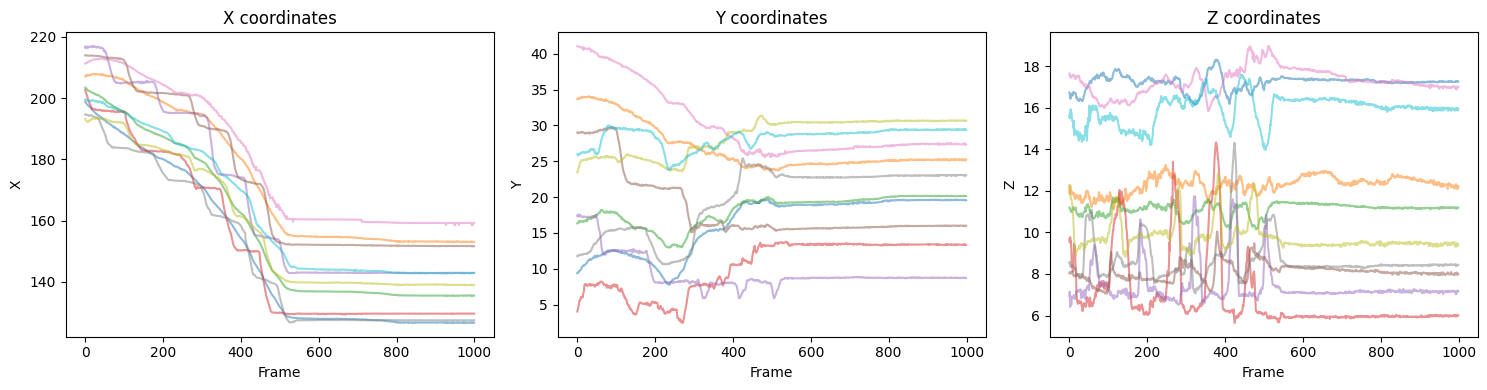

In [10]:
# Quick visualization of keypoint trajectories
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

coords = coordinates[rec_name]
n_frames_to_plot = min(1000, coords.shape[0])

for ax, dim, label in zip(axes, range(3), ['X', 'Y', 'Z']):
    for kp_idx in range(0, len(bodyparts), 5):  # Plot every 5th keypoint
        ax.plot(coords[:n_frames_to_plot, kp_idx, dim], alpha=0.5, label=bodyparts[kp_idx])
    ax.set_xlabel('Frame')
    ax.set_ylabel(label)
    ax.set_title(f'{label} coordinates')

plt.tight_layout()
plt.show()

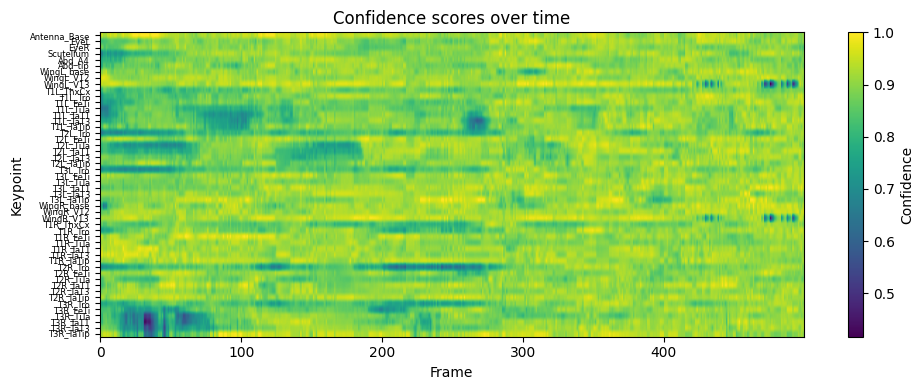

Mean confidence: 0.903
Min confidence: 0.417
Keypoints with low confidence (<0.5): 0


In [11]:
# Check confidence scores
confs = confidences[rec_name]

plt.figure(figsize=(10, 4))
plt.imshow(confs[:500].T, aspect='auto', cmap='viridis')
plt.colorbar(label='Confidence')
plt.xlabel('Frame')
plt.ylabel('Keypoint')
plt.yticks(range(len(bodyparts)), bodyparts, fontsize=6)
plt.title('Confidence scores over time')
plt.tight_layout()
plt.show()

# Summary stats
print(f"Mean confidence: {confs.mean():.3f}")
print(f"Min confidence: {confs.min():.3f}")
print(f"Keypoints with low confidence (<0.5): {(confs.mean(axis=0) < 0.5).sum()}")

## Setup Keypoint MoSeq Project

In [12]:
# Create project directory
project_dir = '/home/user/src/3d_tracking_dataset/kpms_fly_project_test'

# Initialize project (creates config.yml)
# Use overwrite=True if re-running, or check if it exists first
import os
if not os.path.exists(os.path.join(project_dir, 'config.yml')):
    kpms.setup_project(project_dir)
    print(f"Created new project at {project_dir}")
else:
    print(f"Project already exists at {project_dir}")

Project already exists at /home/user/src/3d_tracking_dataset/kpms_fly_project_test


In [13]:
# Load and review config
config = kpms.load_config(project_dir)

print("Current config:")
print(f"  Bodyparts: {len(config.get('bodyparts', []))}")
print(f"  Skeleton edges: {len(config.get('skeleton', []))}")
print(f"  Anterior bodyparts: {config.get('anterior_bodyparts')}")
print(f"  Posterior bodyparts: {config.get('posterior_bodyparts')}")

Current config:
  Bodyparts: 50
  Skeleton edges: 44
  Anterior bodyparts: ['Antenna_Base']
  Posterior bodyparts: ['Abd_tip']


In [14]:
# Save updated config using update_config
kpms.update_config(
    project_dir,
    bodyparts=bodyparts,
    skeleton=skeleton_edges,
    anterior_bodyparts=['Antenna_Base'],
    posterior_bodyparts=['Abd_tip'],
    use_bodyparts=bodyparts
)
print("Config saved")

Config saved


## Format Data for Modeling

In [15]:
# Reload config
config = kpms.load_config(project_dir)

# Format data (centers, aligns, and computes velocities)
data, metadata = kpms.format_data(coordinates, confidences, **config)

print("Data formatted successfully!")
print(f"Keys in data: {list(data.keys())}")

Data formatted successfully!
Keys in data: ['Y', 'conf', 'mask']


## Fit PCA

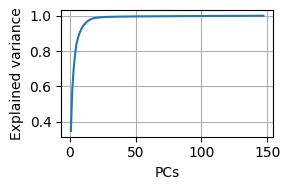

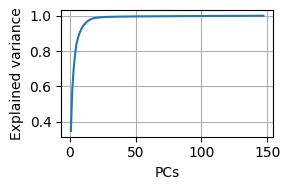

In [16]:
# Fit PCA to the data
pca = kpms.fit_pca(**data, **config)

# Save PCA
kpms.save_pca(pca, project_dir)

# Plot explained variance
kpms.plot_scree(pca, project_dir=project_dir)

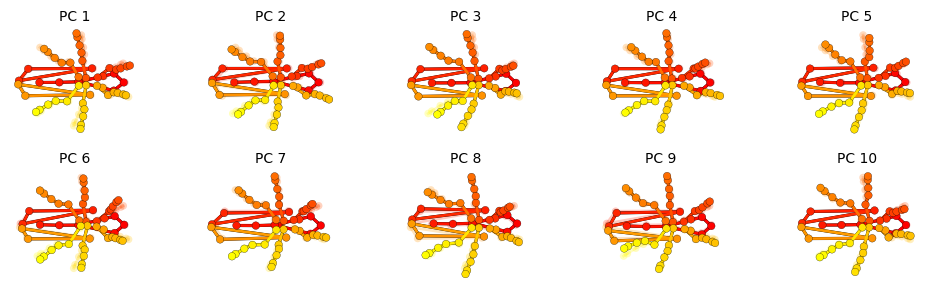

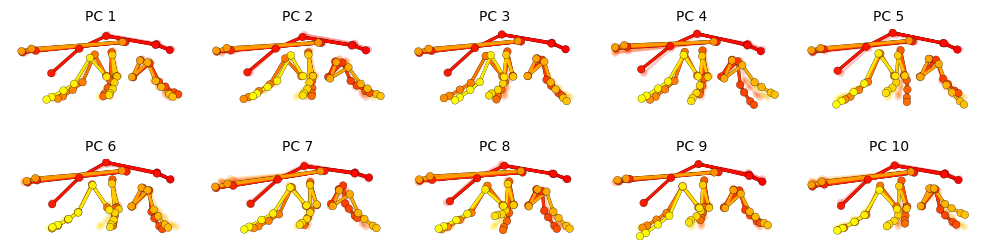

Saved interactive plot to /home/user/src/3d_tracking_dataset/kpms_fly_project_test/pcs.html


In [17]:
# Visualize principal components
kpms.plot_pcs(pca, project_dir=project_dir, **config)

## Fit AR-HMM Model

Model initialized with keys: ['seed', 'hypparams', 'noise_prior', 'params', 'states']
Outputs will be saved to /home/user/src/3d_tracking_dataset/kpms_fly_p
roject_test/2026_02_05-14_33_33


 49%|█████████████████▏                 | 25/51 [00:38<00:28,  1.12s/it]

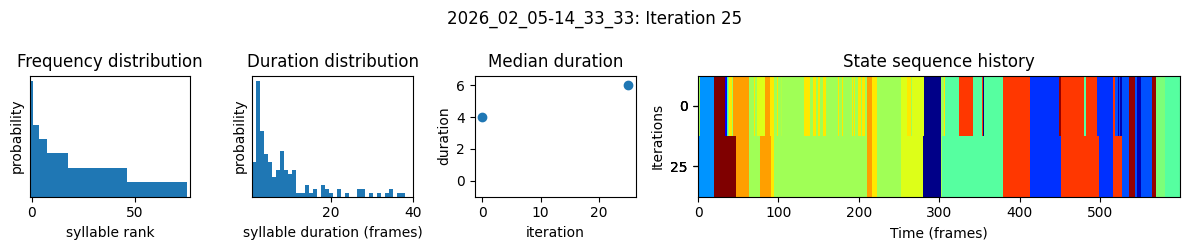

 98%|██████████████████████████████████▎| 50/51 [01:06<00:01,  1.14s/it]

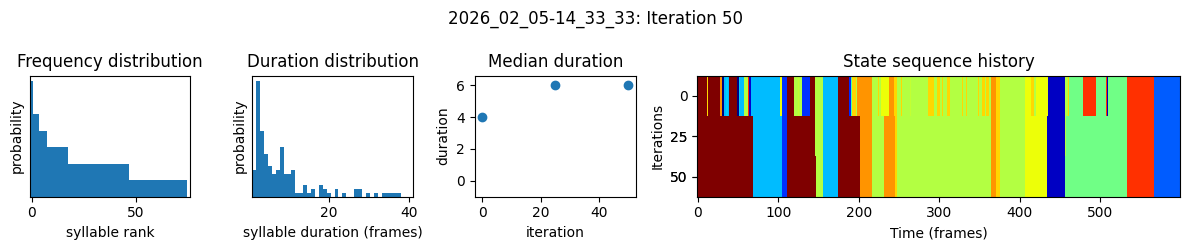

100%|███████████████████████████████████| 51/51 [01:08<00:00,  1.34s/it]

Model fitted: 2026_02_05-14_33_33


In [18]:
# Initialize the model
model = kpms.init_model(data=data, pca=pca, **config)
print(f"Model initialized with keys: {list(model.keys())}")

# Fit the keypoint-moseq model
# This may take a while depending on data size
model, model_name = kpms.fit_model(
    model=model,
    data=data,
    metadata=metadata,
    project_dir=project_dir,
    num_iters=50,  # Increase for better results
    save_every_n_iters=25
)

print(f"Model fitted: {model_name}")

In [19]:
# Create model directory if needed and plot progress
import os
model_dir = os.path.join(project_dir, model_name)
os.makedirs(model_dir, exist_ok=True)

# Plot model fitting progress (if available)
# kpms.plot_progress(model, project_dir=project_dir)

## Extract and Analyze Results

In [23]:
# Extract syllable labels and other results
results = kpms.extract_results(model, metadata, project_dir=project_dir, model_name=model_name)

print(f"Results keys: {list(results.keys())}")
for rec in results:
    print(f"  {rec}: {list(results[rec].keys())}")

Saved results to /home/user/src/3d_tracking_dataset/kpms_fly_project_t
est/2026_02_05-14_33_33/results.h5
Results keys: ['data3D']
  data3D: ['syllable', 'latent_state', 'centroid', 'heading']


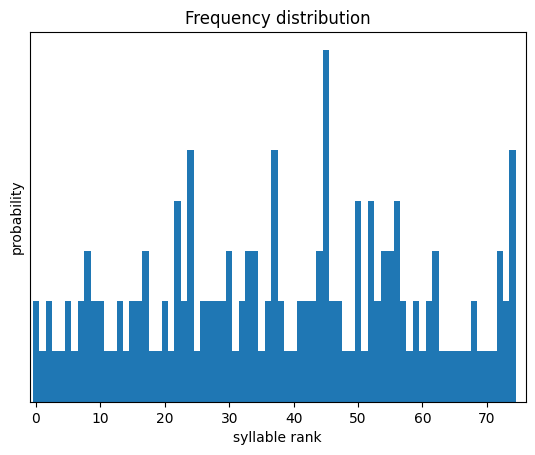

In [22]:
# Plot syllable frequencies
fig, ax = kpms.plot_syllable_frequencies(results=results)
plt.show()

Saving dendrogram plot to /home/user/src/3d_tracking_dataset/kpms_fly_project_test/2026_02_05-14_33_33/similarity_dendrogram


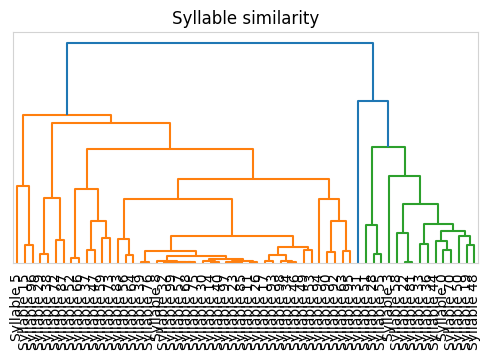

In [24]:
# Plot syllable similarity dendrogram
# Requires coordinates and fps
kpms.plot_similarity_dendrogram(
    coordinates=coordinates,
    results=results,
    project_dir=project_dir,
    model_name=model_name,
    fps=config.get('fps', 30),  # Set your framerate
    use_bodyparts=config.get('use_bodyparts')
)

In [28]:
import bokeh.io
bokeh.io.output_notebook()
import panel as pn
pn.extension()

kpms.interactive_group_setting(project_dir, model_name)
kpms.interactive_group_setting(project_dir, model_name)


Loading BokehJS ...

BokehModel(combine_events=True, render_bundle={'docs_json': {'809f5b57-08d0-401f-b761-be57cd6d6ff4': {'version…

In [ ]:
moseq_df = kpms.compute_moseq_df(project_dir, model_name, smooth_heading=True)
moseq_df

,name,centroid_x,centroid_y,centroid_z,heading,angular_velocity,velocity_px_s,syllable,frame_index,group,onset
0,data3D,203.644221,22.271249,11.314437,-1.937193,0.000000,0.000000,51,0,default,True
1,data3D,203.419534,21.258766,11.763082,-1.937193,-0.050295,33.899848,51,1,default,False
2,data3D,203.000161,21.418489,12.427674,-1.937193,-0.095771,24.057461,51,2,default,False
3,data3D,202.867043,21.410877,12.197071,-1.957285,-0.132999,7.991290,51,3,default,False
4,data3D,202.853936,21.752150,11.937658,-1.958600,-0.160895,12.866254,51,4,default,False
...,...,...,...,...,...,...,...,...,...,...,...
1995,data3D,139.360506,21.659395,11.651273,-2.904465,-0.046349,9.143422,41,1995,default,False
1996,data3D,139.383694,21.576239,11.443847,-2.904465,-0.044238,6.740199,41,1996,default,False
1997,data3D,139.280061,21.521859,11.584667,-2.912942,-0.039297,5.493132,41,1997,default,False
1998,data3D,139.506674,21.538447,11.708863,-2.914444,-0.030037,7.768388,41,1998,default,False


In [ ]:
# Generate trajectory plots for each syllable (3D data)
# This may take a while
kpms.generate_trajectory_plots(
    coordinates=coordinates,
    results=results,
    project_dir=project_dir,
    model_name=model_name,
    skeleton=config.get('skeleton', []),
    use_bodyparts=config.get('use_bodyparts'),
    fps=config.get('fps', 30),  # Set your framerate
    save_gifs=False,  # Set True to generate animated gifs
    interactive=True  # 3D interactive plots
)

Saving trajectory plots to /home/user/src/3d_tracking_dataset/kpms_fly_project_test/2026_02_04-14_50_42/trajectory_plots


ValueError: No syllables with sufficient instances to generate a trajectory. This
usually occurs when there is not enough inut data or when all frames
have the same syllable label (use `plot_syllable_frequencies` to check
if this is the case)

## Visualize Syllable Sequence

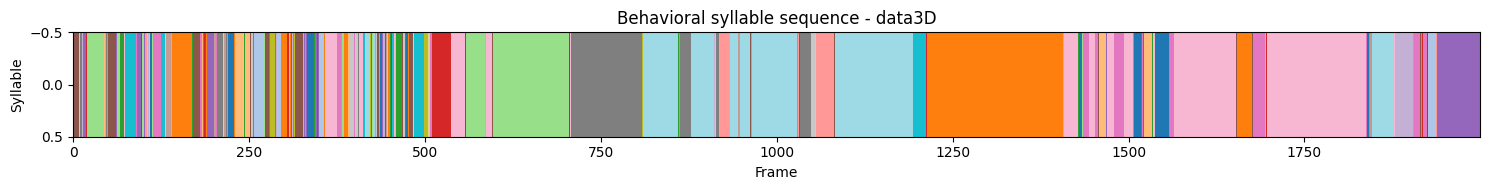

Unique syllables: 68
Total frames: 2000


In [ ]:
# Get syllable labels for first recording
rec_name = list(results.keys())[0]
syllables = results[rec_name]['syllable']

# Plot syllable sequence
fig, ax = plt.subplots(figsize=(15, 2))
ax.imshow(syllables[None, :], aspect='auto', cmap='tab20')
ax.set_xlabel('Frame')
ax.set_ylabel('Syllable')
ax.set_title(f'Behavioral syllable sequence - {rec_name}')
plt.tight_layout()
plt.show()

print(f"Unique syllables: {len(np.unique(syllables))}")
print(f"Total frames: {len(syllables)}")

## Save Results for Further Analysis

In [ ]:
# Save syllables to CSV for each recording
output_dir = Path(project_dir) / 'syllable_labels'
output_dir.mkdir(exist_ok=True)

for rec_name in results.keys():
    syllables = results[rec_name]['syllable']
    df = pd.DataFrame({
        'frame': np.arange(len(syllables)),
        'syllable': syllables
    })
    df.to_csv(output_dir / f'{rec_name}_syllables.csv', index=False)
    print(f"Saved: {rec_name}_syllables.csv")

# Egocentric


In [71]:
# Define the egocentric transformation functions
def compute_egocentric_transform(thorax_pos, head_pos, abd_pos):
    """Compute transformation to egocentric (body-centered) coordinates."""
    N = thorax_pos.shape[0]
    
    forward = head_pos - abd_pos
    forward = forward / (np.linalg.norm(forward, axis=1, keepdims=True) + 1e-10)
    
    world_up = np.array([0, 0, 1])
    
    right = np.cross(forward, world_up)
    right = right / (np.linalg.norm(right, axis=1, keepdims=True) + 1e-10)
    
    up = np.cross(right, forward)
    up = up / (np.linalg.norm(up, axis=1, keepdims=True) + 1e-10)
    
    R = np.zeros((N, 3, 3))
    R[:, :, 0] = right
    R[:, :, 1] = forward
    R[:, :, 2] = up
    
    return R, thorax_pos


def transform_to_egocentric(points, R, origin):
    """Transform points to egocentric coordinates."""
    centered = points - origin
    ego_points = np.einsum('nij,nj->ni', R.transpose(0, 2, 1), centered)
    return ego_points


def load_jarvis_3d(csv_path, egocentric=True, thorax_kp='Scutellum', head_kp='Antenna_Base', abd_kp='Abd_A4'):
    """Load JARVIS data3D.csv with optional egocentric transformation."""
    df = pd.read_csv(csv_path, header=[0, 1])
    bodyparts = df.columns.get_level_values(0).unique().tolist()
    
    n_frames = len(df)
    n_keypoints = len(bodyparts)
    
    coords = np.zeros((n_frames, n_keypoints, 3))
    confs = np.zeros((n_frames, n_keypoints))
    
    for i, kp in enumerate(bodyparts):
        coords[:, i, 0] = df[(kp, 'x')].values
        coords[:, i, 1] = df[(kp, 'y')].values
        coords[:, i, 2] = df[(kp, 'z')].values
        confs[:, i] = df[(kp, 'confidence')].values
    
    if egocentric:
        thorax_idx = bodyparts.index(thorax_kp)
        head_idx = bodyparts.index(head_kp)
        abd_idx = bodyparts.index(abd_kp)
        
        thorax_pos = coords[:, thorax_idx, :]
        head_pos = coords[:, head_idx, :]
        abd_pos = coords[:, abd_idx, :]
        
        R, origin = compute_egocentric_transform(thorax_pos, head_pos, abd_pos)
        
        for i in range(n_keypoints):
            coords[:, i, :] = transform_to_egocentric(coords[:, i, :], R, origin)
        
        print(f"Transformed to egocentric coordinates (origin: {thorax_kp})")
    
    rec_name = Path(csv_path).stem
    return {rec_name: coords}, {rec_name: confs}, bodyparts

print("Functions defined")

Functions defined


In [ ]:
# Load data with egocentric transformation
csv_path = '/home/user/src/JARVIS-HybridNet/projects/fly50_V4/predictions/predictions3D/Predictions_3D_20260114-133024/data3D.csv'
skeleton_path = '/home/user/red_data/skeleton/fly50.json'

coordinates, confidences, bodyparts = load_jarvis_3d(
    csv_path,
    egocentric=True,
    thorax_kp='Scutellum',
    head_kp='Antenna_Base', 
    abd_kp='Abd_A4'
)

# Load skeleton
skeleton_nodes, skeleton_edges, skeleton_edges_idx = load_skeleton(skeleton_path)

rec_name = list(coordinates.keys())[0]
print(f"Recording: {rec_name}")
print(f"Shape: {coordinates[rec_name].shape}")
print(f"Keypoints: {len(bodyparts)}")

Transformed to egocentric coordinates (origin: Scutellum)
Recording: data3D
Shape: (1000, 50, 3)
Keypoints: 50


In [73]:
# Setup project (use existing or create new)
project_dir = '/home/user/src/3d_tracking_dataset/kpms_fly_project'

if not os.path.exists(os.path.join(project_dir, 'config.yml')):
    kpms.setup_project(project_dir)
    print(f"Created new project at {project_dir}")
else:
    print(f"Project already exists at {project_dir}")

# Update config
kpms.update_config(
    project_dir,
    bodyparts=bodyparts,
    skeleton=skeleton_edges,
    anterior_bodyparts=['Antenna_Base'],
    posterior_bodyparts=['Abd_tip'],
    use_bodyparts=bodyparts
)

# Reload config
config = kpms.load_config(project_dir)
print(f"Config loaded: {len(config['bodyparts'])} bodyparts, {len(config['skeleton'])} edges")

Project already exists at /home/user/src/3d_tracking_dataset/kpms_fly_project
Config loaded: 50 bodyparts, 44 edges


In [74]:
# Format data
data, metadata = kpms.format_data(coordinates, confidences, **config)
print(f"Data formatted: {list(data.keys())}")

# Fit PCA
pca = kpms.fit_pca(**data, **config)
kpms.save_pca(pca, project_dir)
print("PCA fitted and saved")

Data formatted: ['Y', 'conf', 'mask']
PCA fitted and saved


In [75]:
# Initialize the model
model = kpms.init_model(data=data, pca=pca, **config)
print(f"Model initialized: {list(model.keys())}")

# Fit the model (using more iterations for better results)
model, model_name = kpms.fit_model(
    model=model,
    data=data,
    metadata=metadata,
    project_dir=project_dir,
    num_iters=50,
    save_every_n_iters=None
)

print(f"Model fitted: {model_name}")

Model initialized: ['seed', 'hypparams', 'noise_prior', 'params', 'states']


100%|███████████████████████████████████| 51/51 [01:00<00:00,  1.18s/it]

Model fitted: 2026_02_03-17_23_09


In [76]:
# Create model directory and extract results
model_dir = os.path.join(project_dir, model_name)
os.makedirs(model_dir, exist_ok=True)

results = kpms.extract_results(model, metadata, project_dir=project_dir, model_name=model_name)

print(f"Results extracted for: {list(results.keys())}")
rec_name = list(results.keys())[0]
syllables = results[rec_name]['syllable']
print(f"Unique syllables: {len(np.unique(syllables))}")
print(f"Total frames: {len(syllables)}")

Saved results to /home/user/src/3d_tracking_dataset/kpms_fly_project/2
026_02_03-17_23_09/results.h5
Results extracted for: ['data3D']
Unique syllables: 54
Total frames: 1000


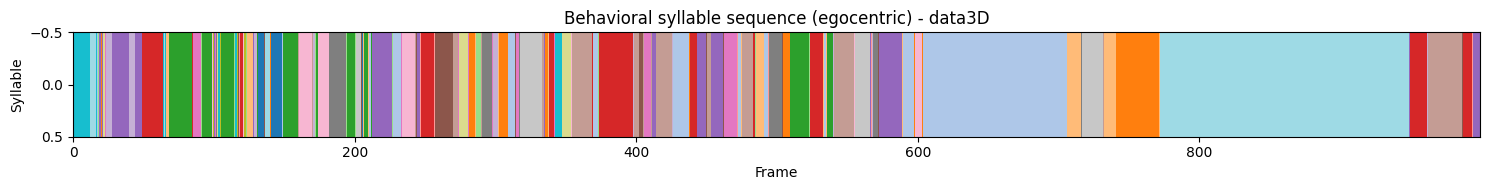

In [77]:
# Plot syllable sequence
fig, ax = plt.subplots(figsize=(15, 2))
ax.imshow(syllables[None, :], aspect='auto', cmap='tab20')
ax.set_xlabel('Frame')
ax.set_ylabel('Syllable')
ax.set_title(f'Behavioral syllable sequence (egocentric) - {rec_name}')
plt.tight_layout()
plt.show()

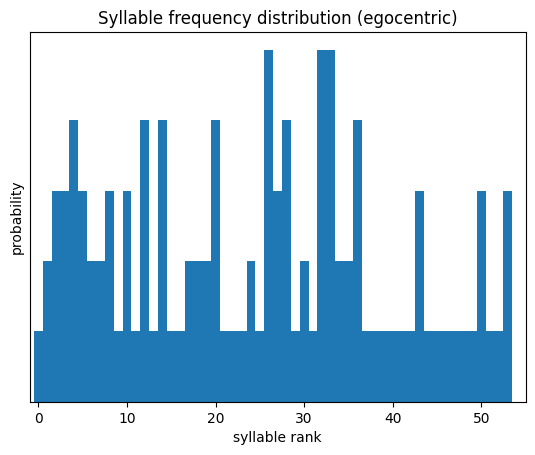

In [78]:
# Plot syllable frequencies
fig, ax = kpms.plot_syllable_frequencies(results=results)
plt.title('Syllable frequency distribution (egocentric)')
plt.show()

In [79]:
# Save syllables to CSV
output_dir = Path(project_dir) / 'syllable_labels'
output_dir.mkdir(exist_ok=True)

for rec in results.keys():
    syls = results[rec]['syllable']
    df_out = pd.DataFrame({
        'frame': np.arange(len(syls)),
        'syllable': syls
    })
    df_out.to_csv(output_dir / f'{rec}_syllables.csv', index=False)
    print(f"Saved: {rec}_syllables.csv")

print(f"\nResults saved to: {output_dir}")

Saved: data3D_syllables.csv

Results saved to: /home/user/src/3d_tracking_dataset/kpms_fly_project/syllable_labels
